In [1]:
import pandas as pd
import numpy as np
from matplotlib.path import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
from streams import Streams
import scipy as sp
from astropy.coordinates import SkyCoord
from astropy.stats import sigma_clip
from astropy import units as u

params = {
    "text.usetex": True,
    "font.family": "serif",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.left": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.size": 2.5,
    "xtick.major.size": 5,
    "ytick.minor.size": 2.5,
    "ytick.major.size": 5,
    "axes.axisbelow": False,
    "figure.dpi": 300,
}
plt.rcParams.update(params)

Initializing galstreams library from master_log... 


# **Analyze Phlegethon Stream**

Reference papers: 

In [2]:
stream = Streams.PHLEGETHON
raw_data = pd.read_csv(f"./data/{stream.name}.csv")

## **Extract the stream**

### **Color Magnitude Diagram filter using isochrones**

Apply a matched filter on the color-magnitude diagram. We define a selection polygon in the (BP-RP, G) CMD that traces an isochrone for this population shifted to the stream's distance.

In [3]:
points = np.column_stack([raw_data["bp_rp"], raw_data["g"]])
path = Path(stream.cmd_polygon)
CMD_MASK = path.contains_points(points)
stream_region = np.abs(raw_data["phi2"]) < 5.0  # within 5° of stream
CMD_MASK = CMD_MASK & stream_region
print(
    f"Isochrone CMD matched filter and stream region cut: {CMD_MASK.sum()} out of {len(raw_data)} stars qualify"
)

Isochrone CMD matched filter and stream region cut: 468985 out of 7830636 stars qualify


### **Directly match with known stream track**

It proved too difficult to obtain the membership from the CMD and PM selections as done for GD-1, so we "cheat" a little by using the known track of the stream to select stars within a certain distance from the track.

In [8]:
DIST_RANGE = (
    stream.track.distance.min() - 0.5 * u.kpc,
    stream.track.distance.max() + 0.5 * u.kpc,
)
DIST_THRESHOLD = 0.05 * u.kpc
DIST_MASK = (raw_data["distance"] > DIST_RANGE[0]) & (
    raw_data["distance"] < DIST_RANGE[1]
)
print(
    f"Number of stars with distance between {DIST_RANGE[0]:.2f} and {DIST_RANGE[1]:.2f}: {np.sum(DIST_MASK)}"
)
DIST_AND_CMD_MASK = DIST_MASK & CMD_MASK
print(f"Adding the CMD cut reduces this to {np.sum(DIST_AND_CMD_MASK)} stars\n")

raw_coords = SkyCoord(
    ra=raw_data["ra"].values * u.deg,
    dec=raw_data["dec"].values * u.deg,
    distance=raw_data["distance"].values * u.kpc,
)
track_coords = SkyCoord(
    ra=stream.track.ra,
    dec=stream.track.dec,
    distance=stream.track.distance,
)

masks = []
separations = []

for i in range(len(track_coords)):
    separations.append(raw_coords[DIST_AND_CMD_MASK].separation_3d(track_coords[i]))
    masks.append(separations[-1] < DIST_THRESHOLD)
    if i % int(len(track_coords) / 10) == 0:
        print(f"Processed {int(np.ceil(i / len(track_coords) * 100))}% of track points")

separations = np.min(np.array(separations), axis=0)

STREAM_MASK = np.array(masks).any(axis=0)
FULL_MASK = np.zeros(len(raw_data), dtype=bool)
FULL_MASK[DIST_AND_CMD_MASK] = STREAM_MASK
print(f"\nNumber of stars within {DIST_THRESHOLD} of the track: {np.sum(FULL_MASK)}")

Number of stars with distance between 2.74 kpc and 4.60 kpc: 1565361
Adding the CMD cut reduces this to 127726 stars

Processed 0% of track points
Processed 10% of track points
Processed 20% of track points
Processed 30% of track points
Processed 40% of track points
Processed 50% of track points
Processed 60% of track points
Processed 70% of track points
Processed 80% of track points
Processed 90% of track points
Processed 100% of track points

Number of stars within 0.05 kpc of the track: 997


### **Save candidates**

In [9]:
candidates = raw_data[FULL_MASK]
candidates.to_csv(f"./stream_candidates/{stream.name}_candidates.csv", index=False)

### **Plots revealing the stream**

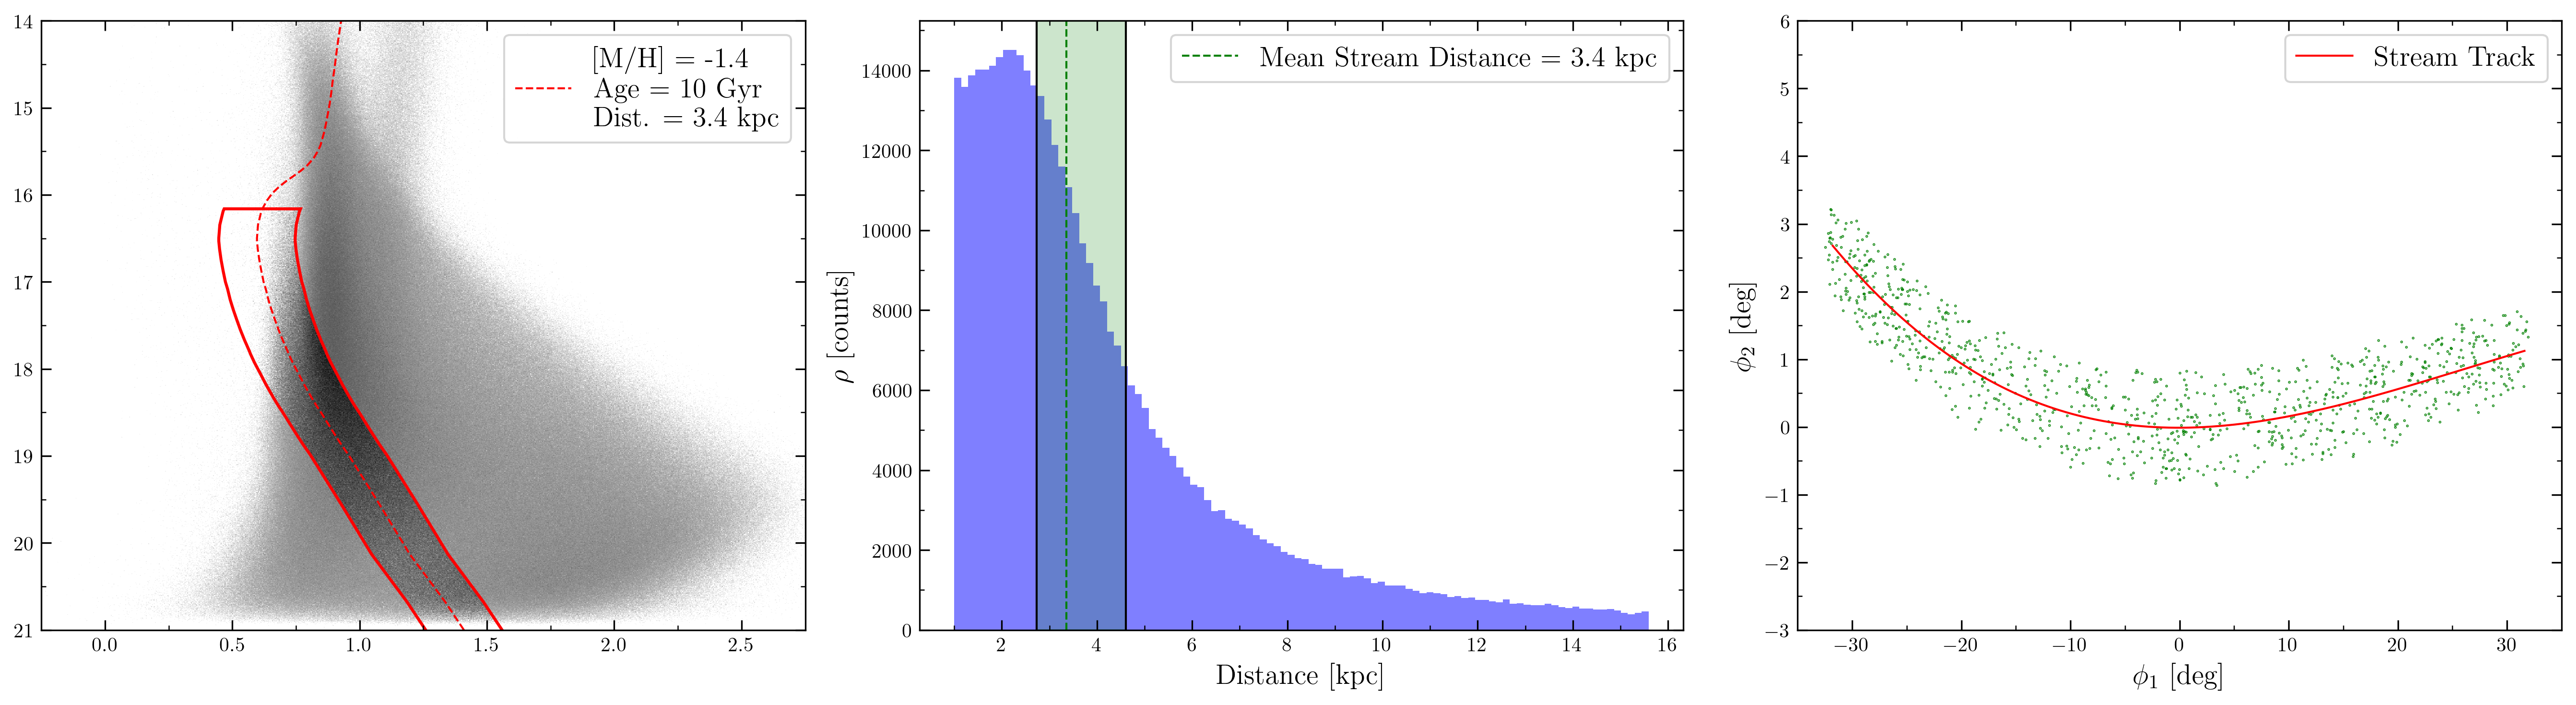

In [10]:
CMD_XLIM = (-0.25, 2.75)
CMD_YLIM = (14, 21)
PHI_XLIM = (-35, 35)
PHI_YLIM = (-3, 6)
COL1_CMAP = "Greys"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax in axes.flatten():
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

axes[0].hist2d(
    raw_data["bp_rp"][CMD_MASK],
    raw_data["g"][CMD_MASK],
    bins=1000,
    cmap=COL1_CMAP,
    norm=mcolors.LogNorm(),
    range=[CMD_XLIM, CMD_YLIM],
)
axes[0].hist2d(
    raw_data["bp_rp"],
    raw_data["g"],
    bins=1000,
    cmap=COL1_CMAP,
    norm=mcolors.LogNorm(),
    range=[CMD_XLIM, CMD_YLIM],
    alpha=0.69,
)
axes[0].plot(
    stream.isochrone["BP_RP"],
    stream.isochrone["Gmag"],
    color="red",
    lw=1,
    linestyle="dashed",
    label=(
        f"[M/H] = {stream.metallicity}\n"
        f"Age = {stream.age_yr / 1e9:.0f} Gyr\n"
        f"Dist. = {stream.distance_kpc:.1f} kpc"
    ),
)
poly = plt.Polygon(
    stream.cmd_polygon, fill=False, edgecolor="red", linewidth=1.5, linestyle="-"
)
axes[0].add_patch(poly)
axes[0].legend(loc="upper right", fontsize=14)
axes[0].invert_yaxis()
axes[1].set_xlabel(r"BP-RP [mag]", fontsize=14)
axes[1].set_ylabel(r"$G$ [mag]", fontsize=14)


axes[1].hist(
    sigma_clip(raw_data["distance"][CMD_MASK]), bins=100, color="blue", alpha=0.5
)
axes[1].axvline(DIST_RANGE[0].value, color="k", linewidth=1)
axes[1].axvline(DIST_RANGE[1].value, color="k", linewidth=1)
axes[1].axvline(
    stream.distance_kpc,
    color="green",
    linewidth=1,
    linestyle="dashed",
    label=f"Mean Stream Distance = {stream.distance_kpc:.1f} kpc",
)
axes1_ylim = axes[1].get_ylim()
axes[1].fill_betweenx(
    [0, axes1_ylim[1]],
    DIST_RANGE[0].value,
    DIST_RANGE[1].value,
    color="green",
    alpha=0.2,
)
axes[1].legend(loc="upper right", fontsize=14)
axes[1].set_ylim(*axes1_ylim)
axes[1].set_xlabel(r"Distance [kpc]", fontsize=14)
axes[1].set_ylabel(r"$\rho$ [counts]", fontsize=14)

axes[2].scatter(
    raw_data["phi1"][FULL_MASK],
    raw_data["phi2"][FULL_MASK],
    color="green",
    s=0.1,
)
axes[2].plot(
    stream.track_phi.phi1,
    stream.track_phi.phi2,
    color="red",
    lw=1,
    label="Stream Track",
)

axes[2].legend(loc="upper right", fontsize=14)
axes[2].set_xlim(*PHI_XLIM)
axes[2].set_ylim(*PHI_YLIM)
axes[2].set_xlabel(r"$\phi_1$ [deg]", fontsize=14)
axes[2].set_ylabel(r"$\phi_2$ [deg]", fontsize=14)

fig.tight_layout()
fig.show()

## **Density profile along the stream**

### **Compute the density profile**

We compute the density profile of the stream by counting the number of stars in bins along the phi1 axis. No need to perform background subtraction as we are using basically pure stream stars. Instead, we do a simple median subtraction to see where there are over or under-densities along the stream.

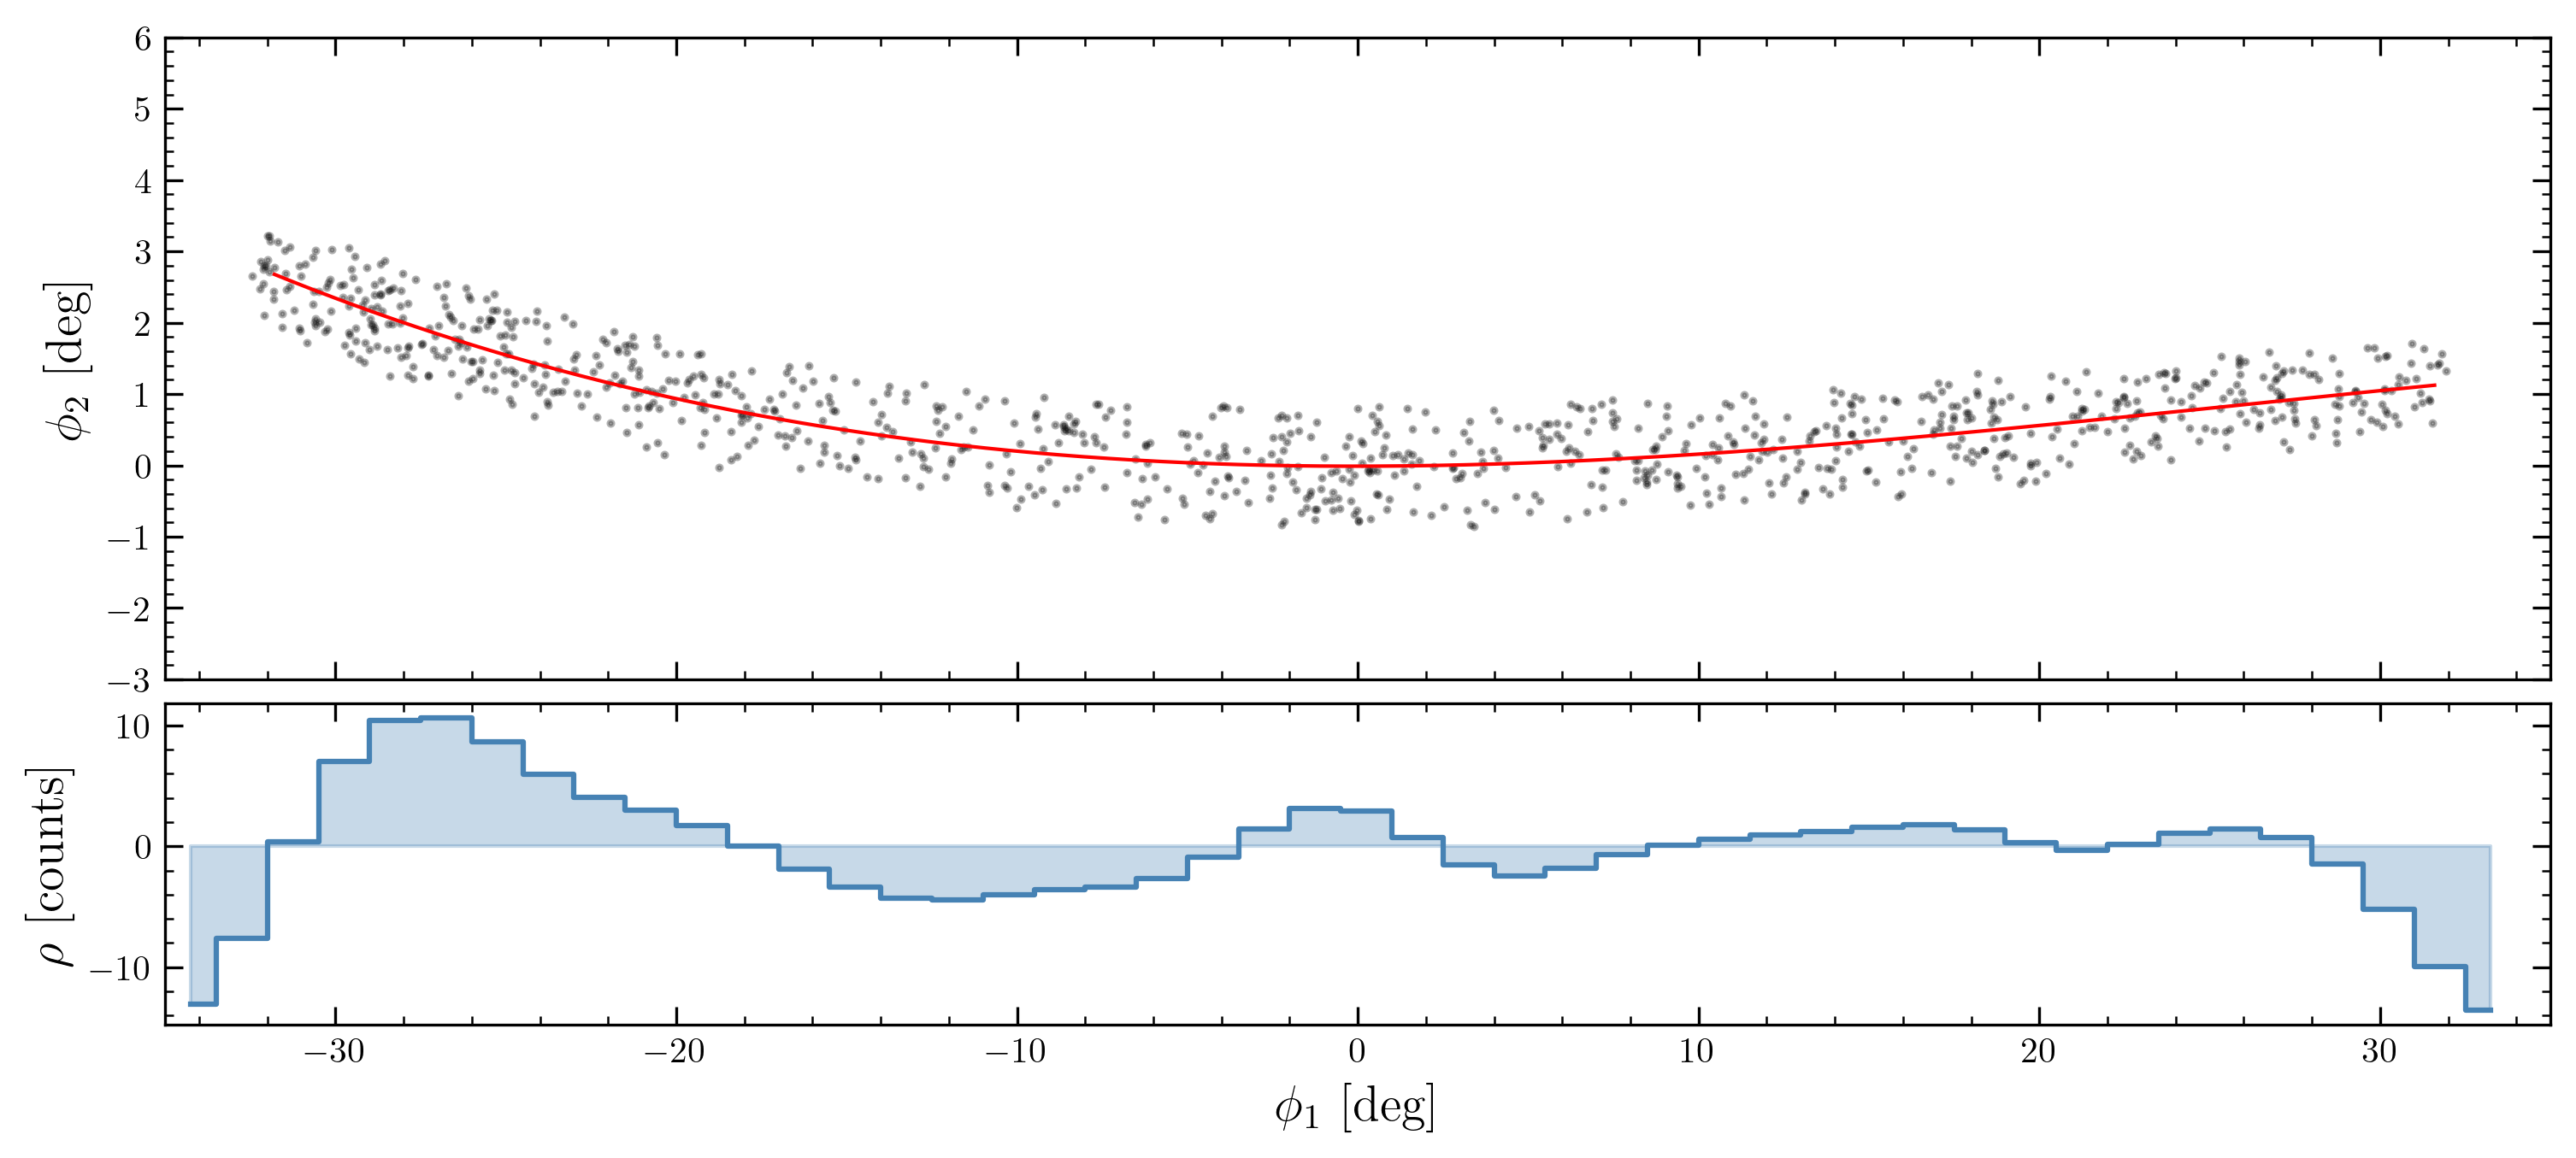

In [11]:
# 1D density
density_bins = np.arange(*PHI_XLIM, step=1.5)
density_centers = 0.5 * (density_bins[:-1] + density_bins[1:])
counts = np.histogram(raw_data["phi1"][FULL_MASK], bins=density_bins)[0].astype(float)
median = np.median(counts)
counts -= median

# Smooth
counts_smooth = sp.ndimage.gaussian_filter1d(counts.astype(float), sigma=1.5)


fig, (ax_sky, ax_dens) = plt.subplots(
    2,
    1,
    figsize=(12, 5),
    height_ratios=[2, 1],
    sharex=True,
    gridspec_kw={"hspace": 0.05},
)

ax_sky.scatter(
    raw_data["phi1"][FULL_MASK],
    raw_data["phi2"][FULL_MASK],
    s=2,
    c="k",
    alpha=0.3,
    # rasterized=True,
)
ax_sky.plot(stream.track_phi.phi1, stream.track_phi.phi2, "r-", lw=1)
ax_sky.set_ylim(*PHI_YLIM)
ax_sky.set_ylabel(r"$\phi_2$ [deg]", fontsize=14)

ax_dens.step(density_centers, counts_smooth, where="mid", color="steelblue", lw=1.5)
ax_dens.fill_between(
    density_centers,
    counts_smooth,
    step="mid",
    color="steelblue",
    alpha=0.3,
)
ax_dens.set_xlabel(r"$\phi_1$ [deg]", fontsize=14)
ax_dens.set_ylabel(r"$\rho$ [counts]", fontsize=14)
ax_dens.set_xlim(*PHI_XLIM)
fig.show()